# Поиск объявлений Авито: воспроизводимое решение

**Recall@50 платформы: 0.882277 · 2 452 запроса · локальное предсказание без API**

Выбран вариант **E5-small + E5-base + доменная модель + география + ансамбль**. Dev Recall@50 — **0.9332**, контрольная test — **0.9259**. Оценки платформы приведены отдельно в конце.

Этот notebook заново рассчитывает `answer_reproduced.csv` на CPU из сохранённых индексов, эмбеддингов и моделей, а затем проверяет точное совпадение SHA-256. Готовые ответы не подставляются по `query_id`. Исходный код всех алгоритмов приложен рядом с notebook.

Локальная метрика использует наблюдавшиеся выборы пользователей, а не полную разметку релевантности.

## Метод и границы проверки

1. Разбиение по нормализованным текстам запроса: 80/10/10, seed=42. Все варианты одного текста остаются в одной части.
2. Для ранжировщика равномерно выбраны 8 000 текстов, для dev и test — по 1 200. На текст взят один случайный контекст локации и фильтров.
3. Локальный корпус — все объявления benchmark плюс отсутствующие позитивы экспериментальных запросов. На dev/test позитивы не вставляются в кандидаты поиска.
4. История, прогноз подкатегории и географические статистики обучены только на train-части, дополнительно исключая тексты обучения ранжировщика. Это предотвращает использование собственной метки как признака.
5. Все варианты и параметры выбираются по dev. Test повторно оценивается только после фиксации второй итерации. Это тот же контрольный набор, что в первой итерации, а не новая слепая проверка. Его метки не используются для настройки.

Отсутствие взаимодействия не доказывает нерелевантность. Конкуренты — слабые отрицательные примеры; известные позитивы из обучающего запроса исключены из них.

## Окружение

Перед первым запуском установите зависимости из `requirements-inference.txt` и выполните `python download_artifacts.py` из корня репозитория. Он загрузит проверенный комплект из GitHub Release и проверит SHA-256. Далее notebook работает без сети. Для стандартного запуска достаточно Python 3.12. GPU и PyTorch не нужны: представления текстов уже рассчитаны. Для полной пересборки нужны `requirements.txt`, локальные веса E5 и две GPU; проверены GTX 1080 Ti и PyTorch 2.7.1 + CUDA 11.8.

Данные: [архив задания](https://disk.yandex.ru/d/sNhfo0YOjGtufg). SHA-256 исходного ZIP: `8dd3cba59201bae333c11db89c5111198fa10cc52a70c70bdc57bd6a248fb777`. Подготовительная загрузка отделена от офлайн-обучения и предсказания.

In [1]:
import os
os.environ.update(OMP_NUM_THREADS='6', OPENBLAS_NUM_THREADS='6',
                  HF_HUB_OFFLINE='1', TRANSFORMERS_OFFLINE='1', CUDA_VISIBLE_DEVICES='')
from pathlib import Path
import hashlib, json, subprocess, sys, time
import numpy as np
import pandas as pd
from IPython.display import display
ROOT=Path.cwd()
DATA_DIR=ROOT/'data'
ARTIFACTS_DIR=ROOT/'artifacts'
OUTPUT=ROOT/'answer_reproduced.csv'
report=json.loads((ARTIFACTS_DIR/'final_report.json').read_text())
audit=json.loads((ARTIFACTS_DIR/'data_audit.json').read_text())
print('Выбранный вариант:', report['selected_name'])

Выбранный вариант: E5-small + E5-base + доменная модель + география + ансамбль


## Данные и качество

Идентификаторы остаются строками; регистр и ведущие нули сохраняются. Нормализация Unicode NFKC, регистра, `ё` и пробелов используется для разбиения и лексических признаков. Нейросети получают исходный текст с собственным токенизатором. Пропуски числовых признаков сохраняются и обрабатываются CatBoost.

In [2]:
queries=pd.read_parquet(DATA_DIR/'benchmark_queries.parquet')
items=pd.read_parquet(DATA_DIR/'benchmark_items.parquet',columns=['item_id'])
assert len(queries)==2452 and queries.query_id.is_unique
assert len(items)==189212 and items.item_id.is_unique
assert queries.query_id.str.len().eq(16).all()
assert items.item_id.str.fullmatch('[0-9a-f]{16}').all()
quality=[]
for name in ['train','benchmark_queries','benchmark_items']:
    r=audit[name]
    quality.append({'Таблица':name,'Строк':r['rows'],'Полных дубликатов':r['duplicate_rows'],
                    'Полей с пропусками':sum(v>0 for v in r['missing'].values())})
display(pd.DataFrame(quality))
for name,expected in report['data_sha256'].items():
    with (DATA_DIR/name).open('rb') as stream:
        assert hashlib.file_digest(stream,'sha256').hexdigest()==expected
print('Контрольные суммы трёх Parquet совпали.')

,Таблица,Строк,Полных дубликатов,Полей с пропусками
0,train,497673,30619,4
1,benchmark_queries,2452,0,0
2,benchmark_items,189212,0,5


Контрольные суммы трёх Parquet совпали.


### Отсутствие пересечений между частями

Проверяются нормализованные тексты, а не внутренние идентификаторы. Один и тот же текст не должен попадать одновременно в обучение ранжировщика и отложенную оценку.

In [3]:
from solution import normalize
split=pd.read_parquet(ARTIFACTS_DIR/'split.parquet')
groups={name:pd.read_parquet(ARTIFACTS_DIR/f'queries_{name}.parquet') for name in ['train','dev','test']}
sets={name:set(frame.search_query.map(normalize)) for name,frame in groups.items()}
assert split.normalized_query.is_unique
assert not (sets['train']&sets['dev'] or sets['train']&sets['test'] or sets['dev']&sets['test'])
assert all(len(sets[k])==len(groups[k]) for k in groups)
history=pd.read_parquet(ARTIFACTS_DIR/'history_train.parquet',columns=['search_query'])
history_texts=set(history.search_query.map(normalize))
assert not history_texts&(sets['train']|sets['dev']|sets['test'])
display(pd.DataFrame({'Полное разбиение':split['split'].value_counts(),
                      'Экспериментальные запросы':{k:len(v) for k,v in groups.items()}}))

,Полное разбиение,Экспериментальные запросы
dev,7387,1200
test,7388,1200
train,59098,8000


## Поиск кандидатов

- **BM25:** заголовок с повышенным весом, параметры и начало описания; Snowball stemmer, `k1=1.2`, `b=0.75`. Редкие термины сохраняются (`min_df=1`). Отдельно индексируются заголовки и исторические запросы.
- **Символьный TF-IDF:** n-граммы 3–5 по заголовкам для опечаток и словоформ.
- **E5-small и E5-base:** 384 и 768 измерений. Префиксы `query:`/`passage:`, masked mean pooling, L2-нормализация, до 256 токенов. Используются запрос с фильтрами, текст запроса без фильтров и короткое представление объявления по заголовку и параметрам.
- **География:** исходные координаты и статистики разрешённой истории. Для части поисковых локаций центр оценивается по обучающим взаимодействиям. Дополнительный источник мягко уменьшает семантическую оценку с расстоянием. Глобальные кандидаты сохраняются, жёстких фильтров нет.

Каждый источник возвращает до 200 глобальных и до 200 локальных кандидатов. После объединения удаляются повторные `item_id`. Семантический поиск использует точное скалярное произведение, без приближённого индекса.

## Отбор 50 объявлений

Базовый RRF суммирует `60/(60+rank)` с весами, выбранными на dev. В первой итерации CatBoost PairLogit обучался с 50 конкурентами на запрос, во второй — с 250: 80% сложных по поисковой оценке и 20% случайных из найденных. Позитивы добавляются только при обучении.

Сравниваются PairLogit и Logloss, их смешивание с RRF и подтверждённой моделью первой итерации. Проверены также квоты рекомендаций разных моделей. Конкретный выбранный способ записан в конфигурации — правила едины для всех запросов.

Признаки: оценки и ранги источников, пересечения слов и фильтров, совпадение категории и локации, расстояние, цена, рейтинг, отзывы, популярность и контактные ограничения. MultinomialNB добавляет мягкий прогноз подкатегории. Географические признаки учитывают частоты переходов между локациями и различия между локальными и удалёнными услугами.

`query_id` не используется как признак. Равные оценки разрешаются по `item_id`. После выбора 50 ID сортируются перед записью: метрика зависит от множества, а канонический порядок стабилизирует SHA-256 между платформами.

In [4]:
if report.get('engine')=='ensemble':
    print('Выбранная стратегия:', report['config']['selection'])
else:
    config=report['config']
    print({k:config[k] for k in ['trees','blend_weight'] if k in config})
from advanced import fusion_score
import inspect
print(inspect.getsource(fusion_score))

Выбранная стратегия: {'method': 'rank', 'weights': {'logloss': 0.75, 'base_logloss': 0.25}, 'recall50': 0.9331943988800049}
def fusion_score(x,names,local_weight=1.,extra_weight=1.,base_weight=1.,geo_weight=1.):
    score=np.zeros(len(x),np.float32)
    for i,name in enumerate(names):
        if not name.startswith('rrf_'): continue
        weight=local_weight if name.endswith('_local') else 1.
        if name.startswith(('rrf_dense_title_','rrf_title_bm25_')): weight*=extra_weight
        if name.startswith(('rrf_base','rrf_domain')): weight*=base_weight
        if name.startswith('rrf_geo_dense_'): weight*=geo_weight
        score+=weight*x[:,i]
    return score



### Доменное дообучение как отдельный эксперимент

Если доменный вариант присутствует в сравнении ниже, он получен из E5-small на разрешённой истории: тексты dev, test и обучения ранжировщика исключены. Используется симметричная контрастивная функция с несколькими позитивами; известные положительные пары не становятся внутрибатчевыми негативами. Словарные embeddings фиксируются, обучаются контекстные слои. Параметры и фактическое число шагов сохранены в `e5-domain/training_config.json`.

Сам факт проведения эксперимента не означает, что он выбран. Решение определяется dev-метрикой и конфигурацией в начале notebook.

### Численная воспроизводимость

Смесь с компонентом `base_pair_d8` показала dev 0.933333, но при проверке Linux/macOS отличалось одно объявление в одном запросе: различия FP32 около 10⁻⁷ изменили границу топ-200 кандидатов. Этот компонент исключён из окончательной смеси целиком. Сохранён проверенный вариант с dev 0.933194; никаких исключений для отдельных `query_id` нет. Повторное CPU-предсказание ниже проверяет именно окончательную конфигурацию.

## Сравнение на dev

Все варианты используют одни и те же 1 200 уникальных текстов. Полнота кандидатов — верхняя граница для последующего отбора. Множество вариантов и подбор параметров могут делать dev-оценку оптимистичной; контрольный test и оценка платформы показаны отдельно.

In [5]:
rows=[]
for kind,title,family in [('lexical','Лексический','Лексический'),('dense','E5-small','E5-small'),('dense_meta','E5-small + подкатегория','E5-small')]:
    path=ARTIFACTS_DIR/f'validation_{kind}.json'
    if not path.exists(): continue
    data=json.loads(path.read_text())
    rrf=max(data['grid'],key=lambda r:r['recall50'])
    if kind!='dense_meta':
        rows.append({'Вариант':title+' / RRF','Семейство':family,'Recall@50':rrf['recall50'],'Полнота кандидатов':rrf['candidate_recall']})
    rows.append({'Вариант':title+' / CatBoost + RRF','Семейство':family,
                 'Recall@50':data['selected']['dev_recall50'],'Полнота кандидатов':rrf['candidate_recall']})
for source,title in [('title','Заголовки'),('base','E5-base + география'),('domain','Доменное дообучение')]:
    for loss in ['pair','pair_d8','logloss','logloss_d8']:
        path=ARTIFACTS_DIR/f'advanced_{source}_{loss}.json'
        if not path.exists(): continue
        data=json.loads(path.read_text())
        rows.append({'Вариант':title+' / '+loss,'Семейство':title,'Recall@50':data['recall50'],'Полнота кандидатов':data['candidate_recall']})
    path=ARTIFACTS_DIR/f'ensemble_{source}.json'
    if path.exists():
        data=json.loads(path.read_text())
        rows.append({'Вариант':title+' / ансамбль','Семейство':title,'Recall@50':data['selection']['recall50'],'Полнота кандидатов':data['candidate_recall']})
comparison=pd.DataFrame(rows)
display(comparison.drop(columns='Семейство').style.format({'Recall@50':'{:.4f}','Полнота кандидатов':'{:.4f}'}))

,Вариант,Recall@50,Полнота кандидатов
0,Лексический / RRF,0.7982,0.9188
1,Лексический / CatBoost + RRF,0.8472,0.9188
2,E5-small / RRF,0.8357,0.9596
3,E5-small / CatBoost + RRF,0.8931,0.9596
4,E5-small + подкатегория / CatBoost + RRF,0.8988,0.9596
5,Заголовки / pair,0.8969,0.9629
6,Заголовки / logloss,0.9025,0.9629
7,Заголовки / ансамбль,0.9046,0.9629
8,E5-base + география / pair,0.9299,0.9738
9,E5-base + география / pair_d8,0.9269,0.9738


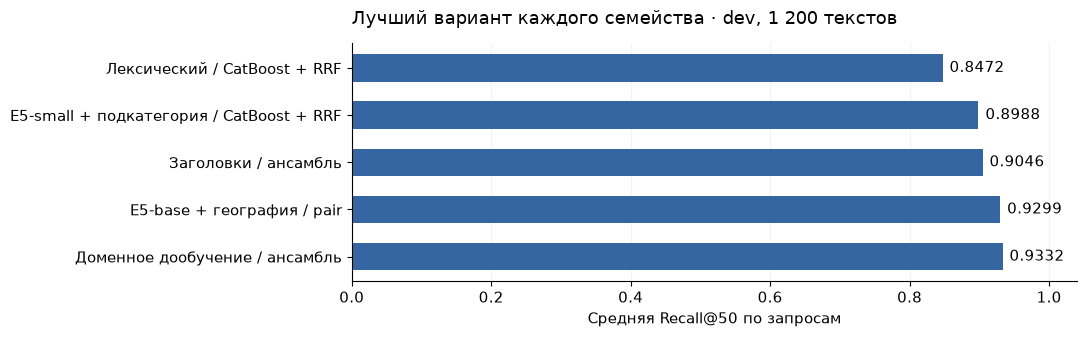

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False})
plot=comparison.loc[comparison.groupby('Семейство',sort=False)['Recall@50'].idxmax()]
fig,ax=plt.subplots(figsize=(11,max(3,len(plot)*.7)))
bars=ax.barh(plot['Вариант'],plot['Recall@50'],height=.58,color='#3566a1')
ax.invert_yaxis();ax.set_xlim(0,1.04);ax.set_xlabel('Средняя Recall@50 по запросам')
ax.set_title('Лучший вариант каждого семейства · dev, 1 200 текстов',loc='left',pad=14)
ax.grid(axis='x',alpha=.15);ax.set_axisbelow(True)
for bar,value in zip(bars,plot['Recall@50']):
    ax.text(value+.01,bar.get_y()+bar.get_height()/2,f'{value:.4f}',va='center')
fig.tight_layout();fig.savefig(ARTIFACTS_DIR/'validation_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

### Контрольная оценка и ошибки

Следующее значение получено после фиксации выбранного варианта. Примеры ошибок относятся только к dev. Ошибка поиска означает отсутствие релевантного объявления среди кандидатов; ошибка отбора — его потерю при выборе 50.

In [7]:
display(pd.DataFrame([{'Выборка':'Контрольная test','Запросов':1200,'Recall@50':report['test_recall50'],
                        'Полнота кандидатов':report['test_candidate_recall']}]))
errors=pd.read_csv(ARTIFACTS_DIR/'dev_errors.csv')
display(errors.groupby(['error_type','same_location']).size().rename('Пропущенных позитивов').reset_index())
display(errors[['query','error_type','relevant_title','same_location']].head(8))

,Выборка,Запросов,Recall@50,Полнота кандидатов
0,Контрольная test,1200,0.925903,0.980417


,error_type,same_location,Пропущенных позитивов
0,retrieval,False,31
1,retrieval,True,3
2,selection,False,26
3,selection,True,26


,query,error_type,relevant_title,same_location
0,домашний мастер муж на час,selection,"Сборка и разборка мебели, установка сантехники",True
1,прогулка на мотоцикле,selection,Квадро safari,True
2,профильная математика егэ,retrieval,Репетитор по математике онлайн ЕГЭ ОГЭ,False
3,ремонт часов ссср,selection,"Ремонт настенных, напольных, каминных часов",False
4,артезианская скважина,selection,Бурение скважины под воду Водоснабжение под ключ,False
5,мастер по поклейки стеновых панелей,selection,"Отделочные работы, монтаж любой сложности",True
6,попутный груз из набережных челнов,retrieval,"Перевозка бульдозеров, грейдеров и дорожной те...",False
7,виниловая наклейка большие,selection,Изготовление табличек / вывесок на 3D-печати,True


## Повторное предсказание на CPU

Команда заново вычисляет кандидатов и оценки, затем проверяет формат и SHA-256. Сохранённый `answer.csv` не читается для получения предсказаний. Внешние API и GPU не используются. Расчёт может занять несколько минут.

In [8]:
started=time.monotonic()
completed=subprocess.run([sys.executable,str(ROOT/'reproduce.py'),'--data-dir',str(DATA_DIR),
    '--artifacts-dir',str(ARTIFACTS_DIR),'--output',str(OUTPUT)],cwd=ROOT,
    check=True,capture_output=True,text=True)
print('\n'.join(completed.stdout.replace(str(ROOT)+'/','').splitlines()[-4:]))
print(f'CPU-предсказание: {time.monotonic()-started:.1f} с')

23:31:04 advanced domain 2416 2452 training False
23:31:38 saved ensemble answer_reproduced.csv
23:31:41 VALID 2452 queries, 50 unique existing items each; sha256 2b8d52769712bb26ffd8b0f75ceceae1a7aec7eac474a0426a3058bafcc45def
Результат точно воспроизведён: answer_reproduced.csv
CPU-предсказание: 309.6 с


### Проверка всех идентификаторов и граничных случаев

Проверяются точное множество `query_id`, две колонки, по 50 уникальных существующих `item_id` и сохранение регистра. Тесты покрывают пустые тексты, неизвестную локацию, пропуски чисел, отсутствие лексических совпадений, равные оценки, географическое сглаживание и удаление повторов при квотах.

In [9]:
from solution import validate
validation=validate(DATA_DIR,OUTPUT)
assert validation['sha256']==report['answer_sha256']
answer=pd.read_csv(OUTPUT,dtype=str)
display(answer.assign(answer=answer.answer.str.slice(0,85)+' …').head(3))
tests=subprocess.run([sys.executable,'-m','unittest','-q','test_solution','test_advanced'],
                     cwd=ROOT,capture_output=True,text=True,check=True)
print(tests.stderr.strip())

23:31:42 VALID 2452 queries, 50 unique existing items each; sha256 2b8d52769712bb26ffd8b0f75ceceae1a7aec7eac474a0426a3058bafcc45def


,query_id,answer
0,70DfDUpwjxB4lzFd,0a32e88bbfb35c29 1308d41ffd1cc3a6 14d535285758...
1,JTrdTaZJvSiLPkXj,01fbbfc288257fca 03bd017cc869bb9c 0529307cdfbe...
2,LZCZNoVG4AFUkVRJ,005a523a0efbc62b 08a5a810e06168af 0a2a31298822...


----------------------------------------------------------------------
Ran 9 tests in 0.190s

OK


## Полная пересборка и open-source компоненты

Команды предсказания приведены в `README.md`, полный цикл подготовки и обучения — в `docs/TRAINING.md`. Используйте новый каталог артефактов, чтобы старые кэши не подменяли пересчёт. Загрузка исходного архива и открытых весов выполняется отдельно. Стандартное воспроизведение этого notebook работает из зафиксированных артефактов.

Использованы NumPy, pandas, PyArrow, SciPy, scikit-learn, NLTK/Snowball, CatBoost, PyTorch, Transformers, Jupyter и Matplotlib. Модели [multilingual-e5-small](https://huggingface.co/intfloat/multilingual-e5-small) и [multilingual-e5-base](https://huggingface.co/intfloat/multilingual-e5-base) распространяются под MIT; конкретные ревизии и контрольные суммы сохранены. Ранжирование основано на [CatBoost](https://catboost.ai/docs/en/concepts/loss-functions-ranking).

Ограничения: положительные метки неполны, описания обрезаются, локальный корпус дополнен позитивами, географические статистики отражают поведение пользователей. Dev ограничен 1 200 текстами и используется для выбора нескольких вариантов. Полное переобучение в другом окружении может отличаться численно; точное воспроизведение CSV проверено из приложенных артефактов.

## Подтверждённые оценки платформы

Журнал содержит только сообщённые пользователем отправки. Используется суммарная метрика, без восстановления скрытой разметки и без правил для отдельных `query_id`. Общий лимит — семь попыток.

In [10]:
journal=json.loads((ROOT/'submissions.json').read_text())
display(pd.DataFrame(journal['attempts'])[['file','recall50','submitted_by']])
print('Подтверждённых отправок:',len(journal['attempts']))
print('Отправок агентом:',journal['submitted_by_agent'])

,file,recall50,submitted_by
0,answer_baseline.csv,0.756185,user
1,answer_lexical_ranker.csv,0.791763,user
2,answer_hybrid.csv,0.833643,user
3,answer_e5_base.csv,0.875740,user
4,answer.csv,0.882277,user


Подтверждённых отправок: 5
Отправок агентом: 0
